In [31]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [33]:
from google.colab import files
uploaded = files.upload()

Saving disease_dataset.csv to disease_dataset (2).csv


In [34]:
df = pd.read_csv("disease_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Fever,Cough,Headache,BP,Sugar,Cholesterol,Medical_History,Disease
0,1,25,Male,1,1,0,120,85,180,NaN,Flu
1,2,45,Female,0,1,1,140,160,220,Diabetes,Heart Disease
2,3,35,Male,1,1,1,130,120,200,NaN,Flu
3,4,50,Female,0,0,1,150,180,240,Hypertension,Heart Disease
4,5,23,Male,1,1,0,110,90,170,NaN,Flu


In [35]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Patient_ID       20 non-null     int64 
 1   Age              20 non-null     int64 
 2   Gender           20 non-null     object
 3   Fever            20 non-null     int64 
 4   Cough            20 non-null     int64 
 5   Headache         20 non-null     int64 
 6   BP               20 non-null     int64 
 7   Sugar            20 non-null     int64 
 8   Cholesterol      20 non-null     int64 
 9   Medical_History  10 non-null     object
 10  Disease          20 non-null     object
dtypes: int64(8), object(3)
memory usage: 1.8+ KB
None
Patient_ID          0
Age                 0
Gender              0
Fever               0
Cough               0
Headache            0
BP                  0
Sugar               0
Cholesterol         0
Medical_History    10
Disease             0
dtype: int64


In [36]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Medical_History"] = le.fit_transform(df["Medical_History"])
df["Disease"] = le.fit_transform(df["Disease"])

df.head()

,Patient_ID,Age,Gender,Fever,Cough,Headache,BP,Sugar,Cholesterol,Medical_History,Disease
0,1,25,1,1,1,0,120,85,180,2,0
1,2,45,0,0,1,1,140,160,220,0,1
2,3,35,1,1,1,1,130,120,200,2,0
3,4,50,0,0,0,1,150,180,240,1,1
4,5,23,1,1,1,0,110,90,170,2,0


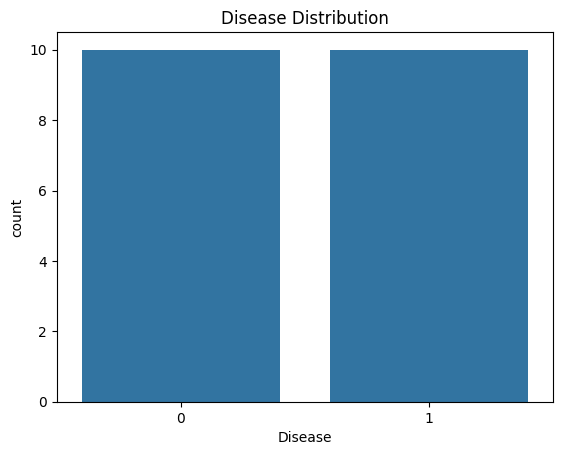

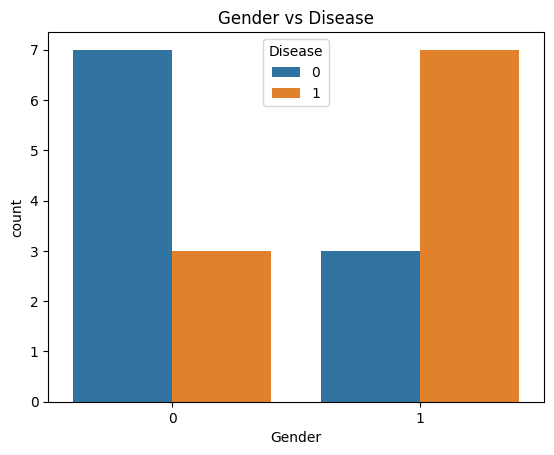

In [37]:
sns.countplot(x='Disease', data=df)
plt.title("Disease Distribution")
plt.show()

sns.countplot(x='Gender', hue='Disease', data=df)
plt.title("Gender vs Disease")
plt.show()

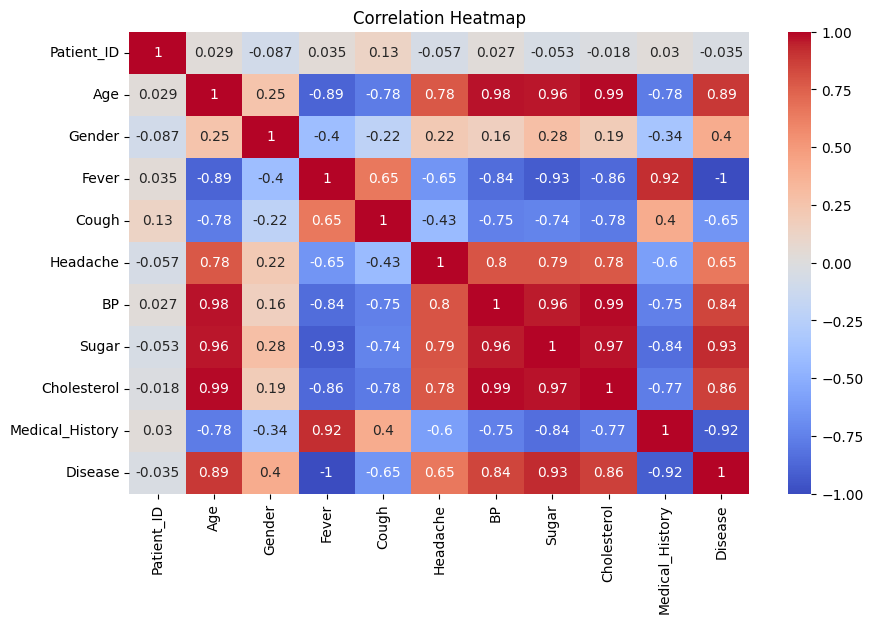

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
X = df.drop(["Disease", "Patient_ID"], axis=1)
y = df["Disease"]

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [42]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

Model: Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



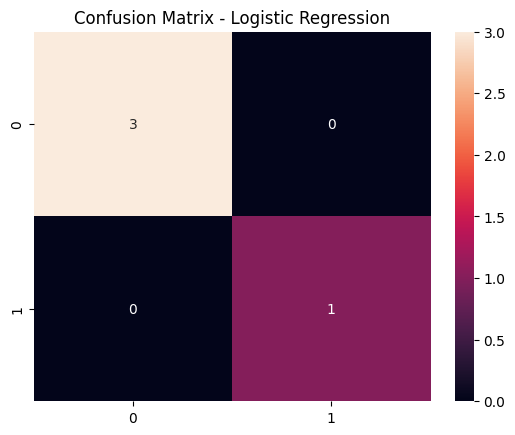

Model: Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



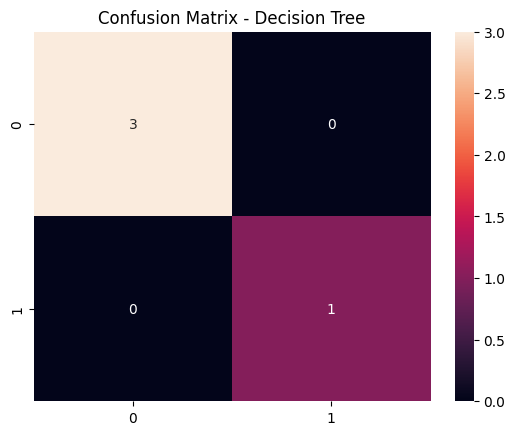

Model: Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



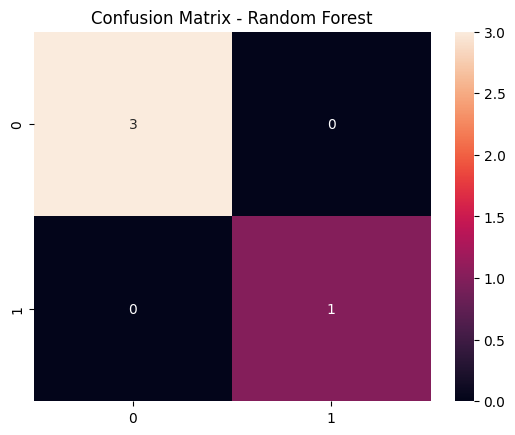

Model: Naive Bayes
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



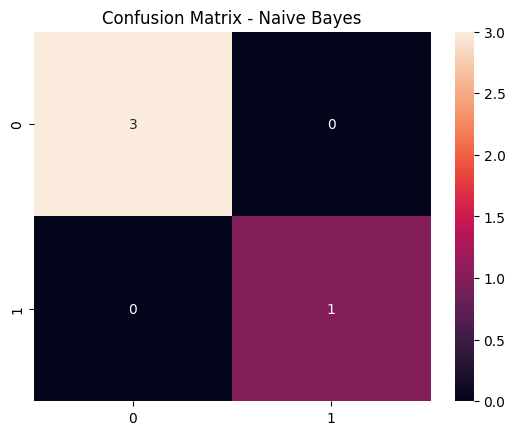

Model: SVM
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



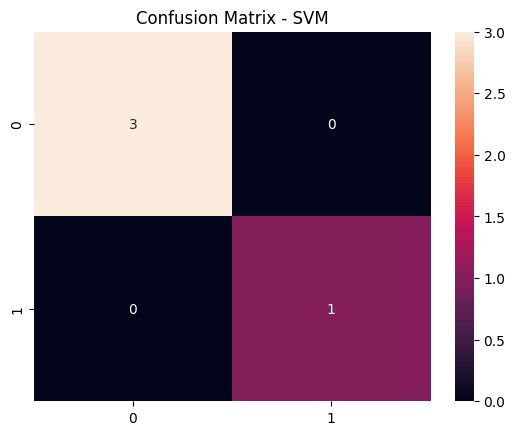

In [43]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Model:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

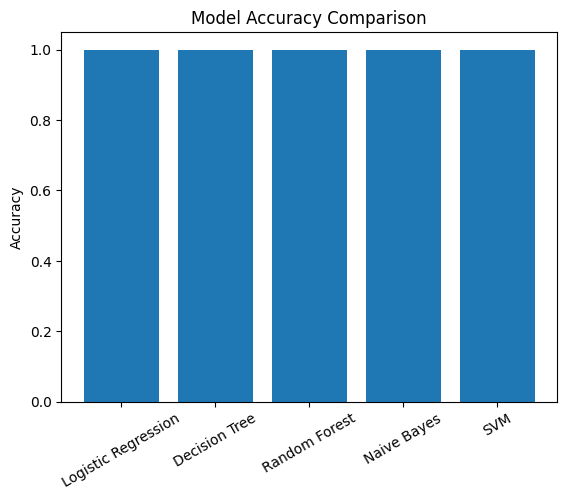

In [44]:
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [45]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

best_model = trained_models[best_model_name]

Best Model: Logistic Regression


In [46]:
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [1. 1. 1. 1. 1.]
Average CV Score: 1.0


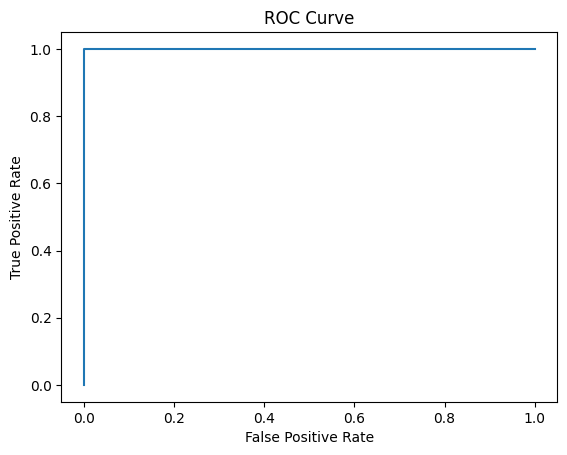

In [47]:
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr)
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

In [48]:
if hasattr(best_model, "feature_importances_"):
    features = X.columns
    importance = best_model.feature_importances_

    plt.barh(features, importance)
    plt.title("Feature Importance")
    plt.show()
else:
    print("Feature importance not available")

Feature importance not available


In [49]:
def predict_disease(age, gender, fever, cough, headache, bp, sugar, chol, history):
    input_data = np.array([[age, gender, fever, cough, headache, bp, sugar, chol, history]])
    input_scaled = scaler.transform(input_data)

    prediction = best_model.predict(input_scaled)[0]

    return "Heart Disease" if prediction == 1 else "Flu"

In [50]:
def risk_level(sugar, chol):
    if sugar > 180 or chol > 240:
        return "High Risk"
    elif sugar > 140:
        return "Medium Risk"
    else:
        return "Low Risk"

In [51]:
result = predict_disease(50, 1, 0, 1, 1, 150, 180, 240, 1)
print("Prediction:", result)
print("Risk:", risk_level(180, 240))

Prediction: Heart Disease
Risk: Medium Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
import pickle

pickle.dump(best_model, open("disease_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [53]:
age = int(input("Enter Age: "))
gender = int(input("Gender (0=Female, 1=Male): "))
fever = int(input("Fever (0/1): "))
cough = int(input("Cough (0/1): "))
headache = int(input("Headache (0/1): "))
bp = int(input("BP: "))
sugar = int(input("Sugar: "))
chol = int(input("Cholesterol: "))
history = int(input("Medical History encoded value: "))

prediction = predict_disease(age, gender, fever, cough, headache, bp, sugar, chol, history)
risk = risk_level(sugar, chol)

print("Predicted Disease:", prediction)
print("Risk Level:", risk)

Enter Age: 21
Gender (0=Female, 1=Male): 0
Fever (0/1): 1
Cough (0/1): 0
Headache (0/1): 1
BP: 120
Sugar: 240
Cholesterol: 310
Medical History encoded value: 5
Predicted Disease: Flu
Risk Level: High Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [54]:
# Simple UI using widgets
import ipywidgets as widgets
from IPython.display import display

# Input fields
age = widgets.IntText(description="Age")
gender = widgets.Dropdown(options=[("Female",0), ("Male",1)], description="Gender")
fever = widgets.Dropdown(options=[("No",0), ("Yes",1)], description="Fever")
cough = widgets.Dropdown(options=[("No",0), ("Yes",1)], description="Cough")
headache = widgets.Dropdown(options=[("No",0), ("Yes",1)], description="Headache")
bp = widgets.IntText(description="BP")
sugar = widgets.IntText(description="Sugar")
chol = widgets.IntText(description="Cholesterol")
history = widgets.IntText(description="History")

button = widgets.Button(description="Predict")

output = widgets.Output()

# Function
def on_button_click(b):
    with output:
        output.clear_output()

        pred = predict_disease(
            age.value, gender.value, fever.value,
            cough.value, headache.value,
            bp.value, sugar.value, chol.value, history.value
        )

        risk = risk_level(sugar.value, chol.value)

        print("🩺 Predicted Disease:", pred)
        print("⚠️ Risk Level:", risk)

button.on_click(on_button_click)

# Display UI
display(age, gender, fever, cough, headache, bp, sugar, chol, history, button, output)

IntText(value=0, description='Age')

Dropdown(description='Gender', options=(('Female', 0), ('Male', 1)), value=0)

Dropdown(description='Fever', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Cough', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Headache', options=(('No', 0), ('Yes', 1)), value=0)

...

IntText(value=0, description='Sugar')

IntText(value=0, description='Cholesterol')

IntText(value=0, description='History')

Button(description='Predict', style=ButtonStyle())

Output()